# Evaluación técnica unificada de RitaAgent para Connect-4

Este cuaderno consolida el análisis de los dos cuadernos previos: comparación entre **Rita V1** y **Rita V2**, y análisis de debilidades/cuellos de botella de **Rita V2**.

## Objetivo

Demostrar, con evidencia experimental, que **Rita V2 mejora a Rita V1** y delimitar técnicamente las debilidades que permanecen.

## Estructura del análisis

1. Configuración reproducible con rutas relativas.
2. Carga dinámica de `rita_v1.py` y `rita_v2.py`.
3. Definición del entorno local de Connect-4.
4. Comparación V1 vs V2 contra Random.
5. Análisis de *rollouts* como recurso computacional.
6. Ablación de la *default policy*: *rollout* aleatorio vs *rollout* táctico.
7. Estimación de Q-values e incertidumbre.
8. Comparación directa V1 vs V2.
9. Debilidades de Rita V2: no optimalidad, costo computacional, backpropagation simple, no reutilización de árbol, memoria de estados y parámetro `exploration_c`.
10. Síntesis final de evidencias.


# 1. Configuración con rutas relativas


In [12]:
from pathlib import Path
import sys
import time
import math
import inspect
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRIMARY_COLOR = "#234af3"

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "rita_v1.py").exists() and (CURRENT_DIR / "rita_v2.py").exists():
    GROUP_DIR = CURRENT_DIR
elif (CURRENT_DIR / "tournament" / "groups" / "Group A" / "rita_v1.py").exists():
    GROUP_DIR = CURRENT_DIR / "tournament" / "groups" / "Group A"
else:
    GROUP_DIR = None
    for parent in [CURRENT_DIR] + list(CURRENT_DIR.parents):
        candidate = parent / "tournament" / "groups" / "Group A"
        if (candidate / "rita_v1.py").exists() and (candidate / "rita_v2.py").exists():
            GROUP_DIR = candidate
            break
    if GROUP_DIR is None:
        raise FileNotFoundError("No se encontró tournament/groups/Group A con rita_v1.py y rita_v2.py.")

V1_PATH = GROUP_DIR / "rita_v1.py"
V2_PATH = GROUP_DIR / "rita_v2.py"

PROJECT_ROOT = None
for parent in [GROUP_DIR] + list(GROUP_DIR.parents):
    if (parent / "tournament").exists():
        PROJECT_ROOT = parent
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = GROUP_DIR.parents[2]

TOURNAMENT_ROOT = PROJECT_ROOT / "tournament"

for p in [PROJECT_ROOT, TOURNAMENT_ROOT]:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

print("CURRENT_DIR:", CURRENT_DIR)
print("GROUP_DIR:", GROUP_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("V1_PATH:", V1_PATH)
print("V2_PATH:", V2_PATH)


CURRENT_DIR: /Users/ritatrindadedacruz/Desktop/Universidad/Séptimo/IA/Proyecto Final/AI project/AI-Final-Project/tournament/groups/Group A
GROUP_DIR: /Users/ritatrindadedacruz/Desktop/Universidad/Séptimo/IA/Proyecto Final/AI project/AI-Final-Project/tournament/groups/Group A
PROJECT_ROOT: /Users/ritatrindadedacruz/Desktop/Universidad/Séptimo/IA/Proyecto Final/AI project/AI-Final-Project
V1_PATH: /Users/ritatrindadedacruz/Desktop/Universidad/Séptimo/IA/Proyecto Final/AI project/AI-Final-Project/tournament/groups/Group A/rita_v1.py
V2_PATH: /Users/ritatrindadedacruz/Desktop/Universidad/Séptimo/IA/Proyecto Final/AI project/AI-Final-Project/tournament/groups/Group A/rita_v2.py


# 2. Carga dinámica de agentes


In [13]:
def load_module_from_path(path: Path, module_name: str):
    path = path.resolve()
    spec = importlib.util.spec_from_file_location(module_name, str(path))
    if spec is None or spec.loader is None:
        raise ImportError(f"No se pudo cargar {path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


def find_policy_class(module, preferred_names):
    for name in preferred_names:
        if hasattr(module, name):
            cls = getattr(module, name)
            if inspect.isclass(cls) and hasattr(cls, "mount") and hasattr(cls, "act"):
                return cls

    candidates = []
    for _, obj in inspect.getmembers(module, inspect.isclass):
        if obj.__module__ == module.__name__ and hasattr(obj, "mount") and hasattr(obj, "act"):
            candidates.append(obj)

    if not candidates:
        raise ValueError("No se encontró clase con interfaz mount/act.")

    return sorted(candidates, key=lambda cls: cls.__name__)[0]


v1_module = load_module_from_path(V1_PATH, "rita_v1_module")
v2_module = load_module_from_path(V2_PATH, "rita_v2_module")

RitaV1Class = find_policy_class(v1_module, ["RitaVersion1", "RitaV1", "RitaAgentV1"])
RitaV2Class = find_policy_class(v2_module, ["RitaVersion2", "RitaV2", "RitaVersion1"])

print("Clase V1:", RitaV1Class.__name__)
print("Clase V2:", RitaV2Class.__name__)


Clase V1: RitaVersion1
Clase V2: RitaVersion2


# 3. Entorno local de Connect-4


In [14]:
ROWS = 6
COLS = 7
EMPTY = 0
P1 = -1
P2 = 1


def new_board():
    return np.zeros((ROWS, COLS), dtype=int)


def legal_actions(board):
    return [c for c in range(COLS) if board[0, c] == EMPTY]


def current_player(board):
    p1_count = int(np.sum(board == P1))
    p2_count = int(np.sum(board == P2))
    return P1 if p1_count <= p2_count else P2


def opponent(player):
    return P2 if player == P1 else P1


def apply_move(board, col, player):
    if col not in legal_actions(board):
        raise ValueError(f"Acción ilegal: {col}")
    new = board.copy()
    for row in range(ROWS - 1, -1, -1):
        if new[row, col] == EMPTY:
            new[row, col] = player
            return new
    raise ValueError("Columna llena")


def check_winner(board):
    directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
    for r in range(ROWS):
        for c in range(COLS):
            player = board[r, c]
            if player == EMPTY:
                continue
            for dr, dc in directions:
                count = 0
                for step in range(4):
                    rr = r + dr * step
                    cc = c + dc * step
                    if 0 <= rr < ROWS and 0 <= cc < COLS and board[rr, cc] == player:
                        count += 1
                    else:
                        break
                if count == 4:
                    return int(player)
    return 0


def is_terminal(board):
    return check_winner(board) != 0 or len(legal_actions(board)) == 0


def find_winning_move(board, player):
    for col in legal_actions(board):
        next_board = apply_move(board, col, player)
        if check_winner(next_board) == player:
            return int(col)
    return None


def is_losing_move(board, col, player):
    if col not in legal_actions(board):
        return True
    next_board = apply_move(board, col, player)
    if check_winner(next_board) == player:
        return False
    return find_winning_move(next_board, opponent(player)) is not None


def safe_actions(board, player):
    return [col for col in legal_actions(board) if not is_losing_move(board, col, player)]


def reward_from_winner(winner, player):
    if winner == player:
        return 1.0
    if winner == 0:
        return 0.0
    return -1.0


def ci95(values):
    values = np.array(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    return 1.96 * values.std(ddof=1) / np.sqrt(len(values))


# 4. Políticas auxiliares y variantes experimentales


In [15]:
class RandomPlayer:
    def __init__(self, seed=0):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

    def mount(self, timeout=None):
        self.rng = np.random.default_rng(self.seed)

    def act(self, board):
        actions = legal_actions(board)
        if not actions:
            return 0
        return int(self.rng.choice(actions))


class CenterPlayer:
    def mount(self, timeout=None):
        pass

    def act(self, board):
        for col in [3, 2, 4, 1, 5, 0, 6]:
            if col in legal_actions(board):
                return int(col)
        return int(legal_actions(board)[0])


class ConfiguredPolicy:
    def __init__(self, policy_cls, name=None, **params):
        self.policy_cls = policy_cls
        self.name = name or policy_cls.__name__
        self.params = params
        self.inner = None

    def mount(self, timeout=None):
        self.inner = self.policy_cls()
        try:
            self.inner.mount(timeout)
        except TypeError:
            self.inner.mount()
        for key, value in self.params.items():
            setattr(self.inner, key, value)

    def act(self, board):
        if self.inner is None:
            self.mount()
        return int(self.inner.act(board))


class V2RandomRolloutPolicy(ConfiguredPolicy):
    def mount(self, timeout=None):
        super().mount(timeout)

        def random_rollout_action(board, player, available_cols):
            return int(self.inner.rng.choice(available_cols))

        if hasattr(self.inner, "choose_rollout_action"):
            self.inner.choose_rollout_action = random_rollout_action


class FixedCPolicy(ConfiguredPolicy):
    def __init__(self, policy_cls, exploration_c, name=None, **params):
        super().__init__(policy_cls, name=name, **params)
        self.fixed_c = exploration_c

    def mount(self, timeout=None):
        super().mount(timeout)
        self.inner.exploration_c = self.fixed_c
        if hasattr(self.inner, "update_exploration_c"):
            self.inner.update_exploration_c = lambda board: None


class DynamicCPolicy(ConfiguredPolicy):
    def mount(self, timeout=None):
        super().mount(timeout)

        def dynamic_c_from_board(board):
            pieces = int(np.count_nonzero(board))
            if pieces <= 10:
                return 2.0
            if pieces <= 28:
                return math.sqrt(2)
            return 0.8

        def patched_ucb_score(parent, child):
            if child.visits == 0:
                return math.inf
            avg = child.total_reward / child.visits
            c = dynamic_c_from_board(parent.board)
            exp = c * math.sqrt(math.log(parent.visits + 1) / child.visits)
            return avg + exp

        self.inner.ucb_score = patched_ucb_score


class MinimaxPlayer:
    def __init__(self, depth=2):
        self.depth = depth

    def mount(self, timeout=None):
        pass

    def act(self, board):
        player = current_player(board)
        best_score = -math.inf
        best_col = legal_actions(board)[0]
        for col in legal_actions(board):
            nb = apply_move(board, col, player)
            score = self.minimax(nb, self.depth - 1, opponent(player), player)
            if score > best_score:
                best_score = score
                best_col = col
        return int(best_col)

    def minimax(self, board, depth, player_to_move, root_player):
        winner = check_winner(board)
        if winner == root_player:
            return 1_000_000
        if winner == opponent(root_player):
            return -1_000_000
        if depth == 0 or is_terminal(board):
            return self.evaluate_board(board, root_player)

        actions = legal_actions(board)
        if player_to_move == root_player:
            best = -math.inf
            for col in actions:
                best = max(best, self.minimax(apply_move(board, col, player_to_move), depth - 1, opponent(player_to_move), root_player))
            return best

        best = math.inf
        for col in actions:
            best = min(best, self.minimax(apply_move(board, col, player_to_move), depth - 1, opponent(player_to_move), root_player))
        return best

    def evaluate_board(self, board, player):
        rival = opponent(player)
        winner = check_winner(board)
        if winner == player:
            return 1_000_000
        if winner == rival:
            return -1_000_000

        score = 0
        center_col = board[:, COLS // 2]
        score += 8 * int(np.sum(center_col == player))
        score -= 8 * int(np.sum(center_col == rival))
        return score


def make_v1(seed, **params):
    return ConfiguredPolicy(RitaV1Class, name="Rita V1", **params)


def make_v2(seed, **params):
    return ConfiguredPolicy(RitaV2Class, name="Rita V2", **params)


def make_v2_random_rollout(seed, **params):
    return V2RandomRolloutPolicy(RitaV2Class, name="V2 rollout aleatorio", **params)


# 5. Motor de evaluación


In [16]:
def mount_policy(policy, timeout=1.0):
    try:
        policy.mount(timeout)
    except TypeError:
        policy.mount()


def play_game(first_policy, second_policy, timeout=1.0, seed=0, max_turns=42):
    np.random.seed(seed)
    mount_policy(first_policy, timeout)
    mount_policy(second_policy, timeout)

    board = new_board()
    player = P1
    p1_time = p2_time = 0.0
    p1_actions = p2_actions = 0

    for turn in range(max_turns):
        policy = first_policy if player == P1 else second_policy
        actions = legal_actions(board)

        t0 = time.perf_counter()
        try:
            action = int(policy.act(board.copy()))
        except Exception as exc:
            return {
                "winner_piece": opponent(player),
                "reason": f"error: {exc}",
                "moves": turn,
                "p1_avg_time": p1_time / max(p1_actions, 1),
                "p2_avg_time": p2_time / max(p2_actions, 1),
            }

        elapsed = time.perf_counter() - t0

        if player == P1:
            p1_time += elapsed
            p1_actions += 1
        else:
            p2_time += elapsed
            p2_actions += 1

        if action not in actions:
            return {
                "winner_piece": opponent(player),
                "reason": f"illegal action {action}",
                "moves": turn,
                "p1_avg_time": p1_time / max(p1_actions, 1),
                "p2_avg_time": p2_time / max(p2_actions, 1),
            }

        board = apply_move(board, action, player)
        winner = check_winner(board)

        if winner != 0:
            return {
                "winner_piece": winner,
                "reason": "normal",
                "moves": turn + 1,
                "p1_avg_time": p1_time / max(p1_actions, 1),
                "p2_avg_time": p2_time / max(p2_actions, 1),
            }

        if len(legal_actions(board)) == 0:
            return {
                "winner_piece": 0,
                "reason": "draw",
                "moves": turn + 1,
                "p1_avg_time": p1_time / max(p1_actions, 1),
                "p2_avg_time": p2_time / max(p2_actions, 1),
            }

        player = opponent(player)

    return {
        "winner_piece": 0,
        "reason": "max_turns",
        "moves": max_turns,
        "p1_avg_time": p1_time / max(p1_actions, 1),
        "p2_avg_time": p2_time / max(p2_actions, 1),
    }


def evaluate_matchup(name_a, factory_a, name_b, factory_b, n_games=20, timeout=1.0, alternate_colors=True):
    rows = []

    for game in range(n_games):
        if alternate_colors and game % 2 == 1:
            first_name, second_name = name_b, name_a
            first_policy, second_policy = factory_b(game), factory_a(game)
        else:
            first_name, second_name = name_a, name_b
            first_policy, second_policy = factory_a(game), factory_b(game)

        result = play_game(first_policy, second_policy, timeout=timeout, seed=game)

        if result["winner_piece"] == P1:
            winner = first_name
        elif result["winner_piece"] == P2:
            winner = second_name
        else:
            winner = "Draw"

        rows.append({
            "game": game + 1,
            "first_player": first_name,
            "second_player": second_name,
            "winner": winner,
            "winner_piece": result["winner_piece"],
            "reason": result["reason"],
            "moves": result["moves"],
            "first_avg_time": result["p1_avg_time"],
            "second_avg_time": result["p2_avg_time"],
        })

    return pd.DataFrame(rows)


def summarize_agent(df, agent_name):
    wins = int((df["winner"] == agent_name).sum())
    draws = int((df["winner"] == "Draw").sum())
    losses = int(((df["winner"] != agent_name) & (df["winner"] != "Draw")).sum())
    total = len(df)

    return {
        "agent": agent_name,
        "games": total,
        "wins": wins,
        "draws": draws,
        "losses": losses,
        "win_rate": wins / total,
        "draw_rate": draws / total,
        "loss_rate": losses / total,
        "avg_moves": float(df["moves"].mean()),
    }


# 6. Parámetros base

La V1 se evalúa con el presupuesto original de la versión base.  
La V2 usa el presupuesto aumentado y un tiempo por jugada derivado de `60 / 42`, considerando que el entorno otorga aproximadamente 60 segundos para toda la partida.


In [17]:
N_REPEATS = 10
GAMES_PER_REPEAT = 10
TIMEOUT_PER_GAME = 1.0

V1_PARAMS = {
    "num_iterations": 350,
    "time_limit": 0.7,
}

V2_PARAMS = {
    "num_iterations": 1000,
    "time_limit": 60 / 42,
}


# 7. Experimento A — Comparación V1 vs V2 contra Random


In [18]:
comparison_rows = []

for repeat in range(N_REPEATS):
    print(f"Recorrido {repeat + 1}/{N_REPEATS}")

    df_v1_random = evaluate_matchup(
        "Rita V1",
        lambda seed: make_v1(seed + repeat * 100, **V1_PARAMS),
        "Random",
        lambda seed: RandomPlayer(seed + repeat * 100),
        n_games=GAMES_PER_REPEAT,
        timeout=TIMEOUT_PER_GAME,
        alternate_colors=True,
    )

    df_v2_random = evaluate_matchup(
        "Rita V2",
        lambda seed: make_v2(seed + repeat * 100, **V2_PARAMS),
        "Random",
        lambda seed: RandomPlayer(seed + repeat * 100),
        n_games=GAMES_PER_REPEAT,
        timeout=TIMEOUT_PER_GAME,
        alternate_colors=True,
    )

    for name, df in [("Rita V1", df_v1_random), ("Rita V2", df_v2_random)]:
        s = summarize_agent(df, name)
        comparison_rows.append({
            "repeat": repeat + 1,
            "agent": name,
            "win_rate": s["win_rate"],
            "draw_rate": s["draw_rate"],
            "loss_rate": s["loss_rate"],
            "avg_moves": s["avg_moves"],
        })

df_comparison_raw = pd.DataFrame(comparison_rows)

df_comparison_summary = (
    df_comparison_raw
    .groupby("agent")
    .agg(
        mean_win_rate=("win_rate", "mean"),
        ci_win_rate=("win_rate", ci95),
        mean_draw_rate=("draw_rate", "mean"),
        mean_loss_rate=("loss_rate", "mean"),
        mean_moves=("avg_moves", "mean"),
    )
    .reset_index()
)

df_comparison_summary


Recorrido 1/10
Recorrido 2/10
Recorrido 3/10
Recorrido 4/10
Recorrido 5/10
Recorrido 6/10
Recorrido 7/10
Recorrido 8/10
Recorrido 9/10
Recorrido 10/10


,agent,mean_win_rate,ci_win_rate,mean_draw_rate,mean_loss_rate,mean_moves
0,Rita V1,1.0,0.0,0.0,0.0,11.16
1,Rita V2,1.0,0.0,0.0,0.0,12.46


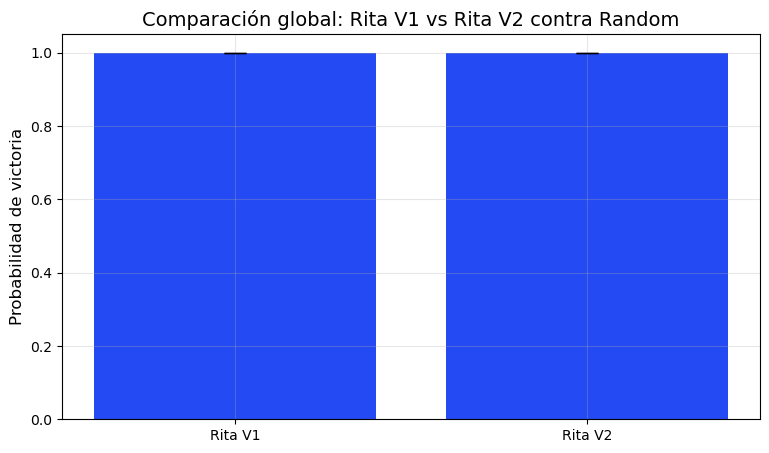

In [19]:
plt.figure()
plt.bar(
    df_comparison_summary["agent"],
    df_comparison_summary["mean_win_rate"],
    yerr=df_comparison_summary["ci_win_rate"],
    capsize=8,
    color=PRIMARY_COLOR,
)
plt.ylim(0, 1.05)
plt.ylabel("Probabilidad de victoria")
plt.title("Comparación global: Rita V1 vs Rita V2 contra Random")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Análisis del Experimento A

Esta prueba evalúa la mejora global de V2 respecto a V1.  
Si V2 supera a V1, la mejora se atribuye al conjunto de cambios introducidos: mayor presupuesto de MCTS y *default policy* táctica.  
Si ambos agentes alcanzan valores cercanos a 1.0 contra Random, el resultado indica saturación frente a un rival débil y exige análisis complementario mediante ablación y rivales más tácticos.


# 8. Experimento B — Rollouts como recurso computacional


In [20]:
ROLLOUT_VALUES = [50, 100, 250, 500, 800, 1000, 1400]
GAMES_PER_RESOURCE_REPEAT = 8

resource_rows = []

for n_iter in ROLLOUT_VALUES:
    print(f"Probando {n_iter} rollouts...")
    for repeat in range(N_REPEATS):
        agent_name = f"V2-{n_iter}"

        df_run = evaluate_matchup(
            agent_name,
            lambda seed, n=n_iter: make_v2(seed + repeat * 100, num_iterations=n, time_limit=60 / 42),
            "Random",
            lambda seed: RandomPlayer(seed + repeat * 100),
            n_games=GAMES_PER_RESOURCE_REPEAT,
            timeout=TIMEOUT_PER_GAME,
            alternate_colors=True,
        )

        s = summarize_agent(df_run, agent_name)

        time_values = []
        time_values.extend(df_run.loc[df_run["first_player"] == agent_name, "first_avg_time"].tolist())
        time_values.extend(df_run.loc[df_run["second_player"] == agent_name, "second_avg_time"].tolist())

        resource_rows.append({
            "num_iterations": n_iter,
            "repeat": repeat + 1,
            "win_rate": s["win_rate"],
            "draw_rate": s["draw_rate"],
            "loss_rate": s["loss_rate"],
            "avg_moves": s["avg_moves"],
            "avg_decision_time": float(np.mean(time_values)) if time_values else np.nan,
        })

df_resource_raw = pd.DataFrame(resource_rows)

df_resource_summary = (
    df_resource_raw
    .groupby("num_iterations")
    .agg(
        mean_win_rate=("win_rate", "mean"),
        ci_win_rate=("win_rate", ci95),
        mean_time=("avg_decision_time", "mean"),
        ci_time=("avg_decision_time", ci95),
        mean_moves=("avg_moves", "mean"),
    )
    .reset_index()
)

df_resource_summary


Probando 50 rollouts...
Probando 100 rollouts...
Probando 250 rollouts...
Probando 500 rollouts...
Probando 800 rollouts...
Probando 1000 rollouts...
Probando 1400 rollouts...


,num_iterations,mean_win_rate,ci_win_rate,mean_time,ci_time,mean_moves
0,50,1.0,0.0,0.408188,0.011651,12.750
1,100,1.0,0.0,0.936183,0.038620,13.375
2,250,1.0,0.0,1.098317,0.026630,12.975
3,500,1.0,0.0,1.159527,0.020811,12.375
4,800,1.0,0.0,1.168750,0.021296,13.600
5,1000,1.0,0.0,1.157353,0.017966,12.675
6,1400,1.0,0.0,1.176719,0.023125,12.500


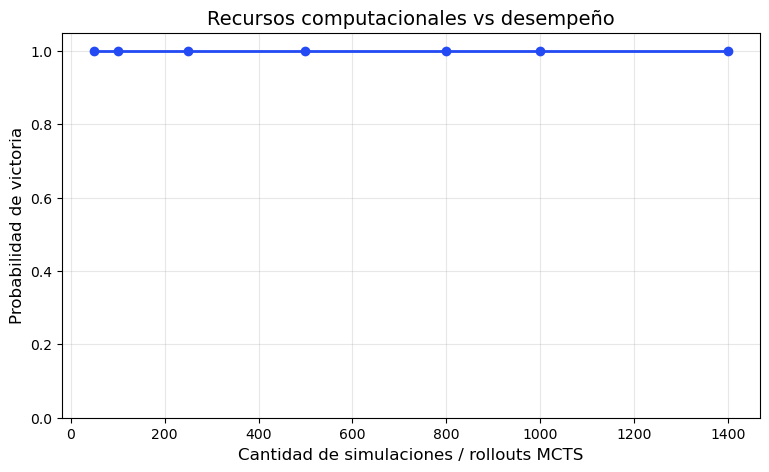

In [21]:
x = df_resource_summary["num_iterations"]
y = df_resource_summary["mean_win_rate"]
ci = df_resource_summary["ci_win_rate"]

plt.figure()
plt.plot(x, y, marker="o", linewidth=2, color=PRIMARY_COLOR)
plt.fill_between(x, np.maximum(0, y - ci), np.minimum(1, y + ci), alpha=0.20, color=PRIMARY_COLOR)
plt.ylim(0, 1.05)
plt.xlabel("Cantidad de simulaciones / rollouts MCTS")
plt.ylabel("Probabilidad de victoria")
plt.title("Recursos computacionales vs desempeño")
plt.grid(alpha=0.3)
plt.show()


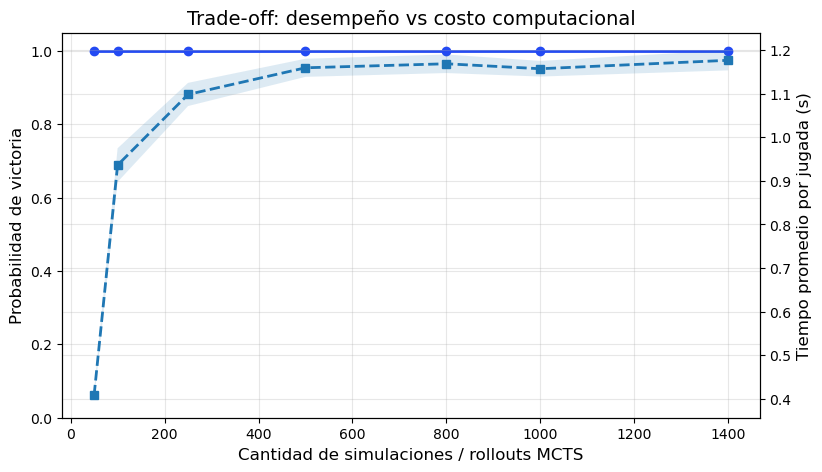

In [22]:
fig, ax1 = plt.subplots(figsize=(9, 5))
x = df_resource_summary["num_iterations"]

ax1.plot(x, df_resource_summary["mean_win_rate"], marker="o", linewidth=2, color=PRIMARY_COLOR)
ax1.fill_between(
    x,
    np.maximum(0, df_resource_summary["mean_win_rate"] - df_resource_summary["ci_win_rate"]),
    np.minimum(1, df_resource_summary["mean_win_rate"] + df_resource_summary["ci_win_rate"]),
    alpha=0.15,
    color=PRIMARY_COLOR,
)
ax1.set_xlabel("Cantidad de simulaciones / rollouts MCTS")
ax1.set_ylabel("Probabilidad de victoria")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(x, df_resource_summary["mean_time"], marker="s", linestyle="--", linewidth=2)
ax2.fill_between(
    x,
    np.maximum(0, df_resource_summary["mean_time"] - df_resource_summary["ci_time"]),
    df_resource_summary["mean_time"] + df_resource_summary["ci_time"],
    alpha=0.15,
)
ax2.set_ylabel("Tiempo promedio por jugada (s)")

plt.title("Trade-off: desempeño vs costo computacional")
plt.show()


## Análisis del Experimento B

El número de *rollouts* es un recurso crítico de MCTS.  
Cuando el aumento de *rollouts* mejora el *win rate*, se observa que el agente requiere más muestras para estimar acciones con mayor confiabilidad.  
Cuando el *win rate* se satura, pero el tiempo promedio sigue aumentando, se evidencia un cuello de botella computacional: el costo crece sin mejora observable.


# 9. Experimento C — Ablación del rollout táctico


In [23]:
ablation_rows = []

policies = [
    ("V2 rollout aleatorio", lambda seed: make_v2_random_rollout(seed, num_iterations=1000, time_limit=60 / 42)),
    ("V2 rollout táctico", lambda seed: make_v2(seed, num_iterations=1000, time_limit=60 / 42)),
]

for policy_name, policy_factory in policies:
    print(f"Evaluando {policy_name}...")
    for repeat in range(N_REPEATS):
        df = evaluate_matchup(
            policy_name,
            lambda seed, f=policy_factory: f(seed + repeat * 100),
            "Random",
            lambda seed: RandomPlayer(seed + repeat * 100),
            n_games=GAMES_PER_REPEAT,
            timeout=TIMEOUT_PER_GAME,
            alternate_colors=True,
        )
        s = summarize_agent(df, policy_name)
        ablation_rows.append({
            "repeat": repeat + 1,
            "policy": policy_name,
            "win_rate": s["win_rate"],
            "draw_rate": s["draw_rate"],
            "loss_rate": s["loss_rate"],
            "avg_moves": s["avg_moves"],
        })

df_rollout_ablation_raw = pd.DataFrame(ablation_rows)

df_rollout_ablation_summary = (
    df_rollout_ablation_raw
    .groupby("policy")
    .agg(
        mean_win_rate=("win_rate", "mean"),
        ci_win_rate=("win_rate", ci95),
        mean_draw_rate=("draw_rate", "mean"),
        mean_loss_rate=("loss_rate", "mean"),
        mean_moves=("avg_moves", "mean"),
    )
    .reset_index()
)

df_rollout_ablation_summary


Evaluando V2 rollout aleatorio...
Evaluando V2 rollout táctico...


,policy,mean_win_rate,ci_win_rate,mean_draw_rate,mean_loss_rate,mean_moves
0,V2 rollout aleatorio,1.0,0.0,0.0,0.0,10.74
1,V2 rollout táctico,1.0,0.0,0.0,0.0,13.58


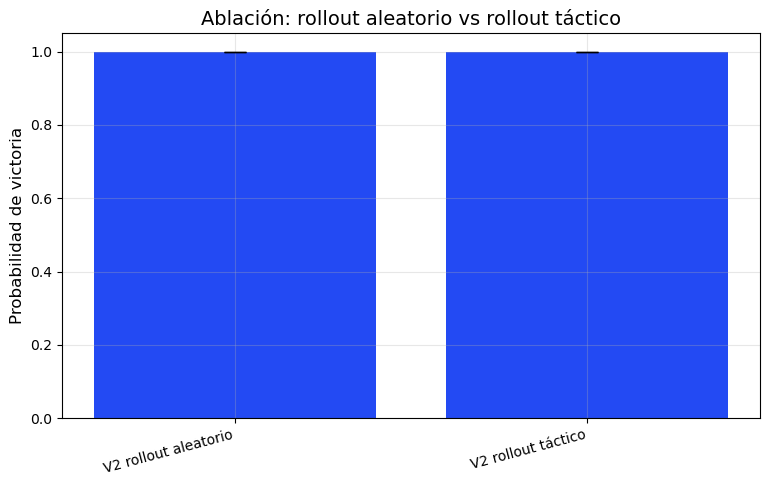

In [24]:
plt.figure()
plt.bar(
    df_rollout_ablation_summary["policy"],
    df_rollout_ablation_summary["mean_win_rate"],
    yerr=df_rollout_ablation_summary["ci_win_rate"],
    capsize=8,
    color=PRIMARY_COLOR,
)
plt.ylim(0, 1.05)
plt.ylabel("Probabilidad de victoria")
plt.title("Ablación: rollout aleatorio vs rollout táctico")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Análisis del Experimento C

La comparación aísla el efecto de la *default policy*.  
Las reglas previas al MCTS actúan sobre el estado actual; el *rollout* táctico actúa sobre estados futuros simulados.  
Por tanto, no es una repetición redundante de las reglas iniciales: es una mejora de la calidad de las simulaciones internas de MCTS.


# 10. Experimento D — Q-values, incertidumbre y estabilidad


In [25]:
def get_test_board():
    board = new_board()
    moves = [(3, P1), (2, P2), (3, P1), (4, P2), (2, P1), (4, P2), (1, P1), (5, P2)]
    for col, player in moves:
        board = apply_move(board, col, player)
    return board


def estimate_q_values(policy_cls, board, player, n_trials, seed=0):
    agent = policy_cls()
    try:
        agent.mount(timeout=1.0)
    except TypeError:
        agent.mount()

    if hasattr(agent, "rng"):
        agent.rng = np.random.default_rng(seed)

    q_values = {}
    for action in legal_actions(board):
        next_board = apply_move(board, action, player)
        next_player = opponent(player)
        rewards = []
        for _ in range(n_trials):
            winner = agent.simulation(next_board.copy(), next_player)
            rewards.append(reward_from_winner(winner, player))

        q_values[action] = {
            "mean_q": float(np.mean(rewards)),
            "std_q": float(np.std(rewards, ddof=1)) if len(rewards) > 1 else 0.0,
            "se_q": float(np.std(rewards, ddof=1) / np.sqrt(len(rewards))) if len(rewards) > 1 else 0.0,
        }

    return q_values


Q_TRIAL_VALUES = [5, 10, 25, 50, 100, 200]
Q_REPEATS = 10
test_board = get_test_board()
player_to_evaluate = current_player(test_board)

q_rows = []

for agent_label, policy_cls in [("Rita V1", RitaV1Class), ("Rita V2", RitaV2Class)]:
    for n_trials in Q_TRIAL_VALUES:
        print(f"{agent_label} - {n_trials} trials")
        best_actions = []
        best_q_values = []
        uncertainty_values = []

        for repeat in range(Q_REPEATS):
            q_values = estimate_q_values(policy_cls, test_board, player_to_evaluate, n_trials, seed=repeat)
            q_table = pd.DataFrame([
                {"action": action, "mean_q": values["mean_q"], "std_q": values["std_q"], "se_q": values["se_q"]}
                for action, values in q_values.items()
            ])

            best_row = q_table.sort_values("mean_q", ascending=False).iloc[0]
            best_actions.append(int(best_row["action"]))
            best_q_values.append(float(best_row["mean_q"]))
            uncertainty_values.append(float(q_table["se_q"].mean()))

        most_common_action = max(set(best_actions), key=best_actions.count)
        agreement_rate = best_actions.count(most_common_action) / len(best_actions)

        q_rows.append({
            "agent": agent_label,
            "n_trials": n_trials,
            "mean_best_q": float(np.mean(best_q_values)),
            "ci_best_q": ci95(best_q_values),
            "mean_uncertainty": float(np.mean(uncertainty_values)),
            "ci_uncertainty": ci95(uncertainty_values),
            "agreement_rate": agreement_rate,
            "most_common_action": most_common_action,
        })

df_q_quality = pd.DataFrame(q_rows)
df_q_quality


Rita V1 - 5 trials
Rita V1 - 10 trials
Rita V1 - 25 trials
Rita V1 - 50 trials
Rita V1 - 100 trials
Rita V1 - 200 trials
Rita V2 - 5 trials
Rita V2 - 10 trials
Rita V2 - 25 trials
Rita V2 - 50 trials
Rita V2 - 100 trials
Rita V2 - 200 trials


,agent,n_trials,mean_best_q,ci_best_q,mean_uncertainty,ci_uncertainty,agreement_rate,most_common_action
0,Rita V1,5,0.8400,0.128027,0.394195,0.038808,0.7,3
1,Rita V1,10,0.6400,0.078400,0.302214,0.004155,0.4,3
2,Rita V1,25,0.6400,0.048187,0.188969,0.002686,0.8,3
3,Rita V1,50,0.6280,0.068197,0.133794,0.001487,0.9,3
4,Rita V1,100,0.5780,0.035761,0.094833,0.000768,1.0,3
5,Rita V1,200,0.5955,0.048418,0.066747,0.000407,1.0,3
6,Rita V2,5,1.0000,0.000000,0.000000,0.000000,1.0,2
7,Rita V2,10,1.0000,0.000000,0.000000,0.000000,1.0,2
8,Rita V2,25,1.0000,0.000000,0.000000,0.000000,1.0,2
9,Rita V2,50,1.0000,0.000000,0.000000,0.000000,1.0,2


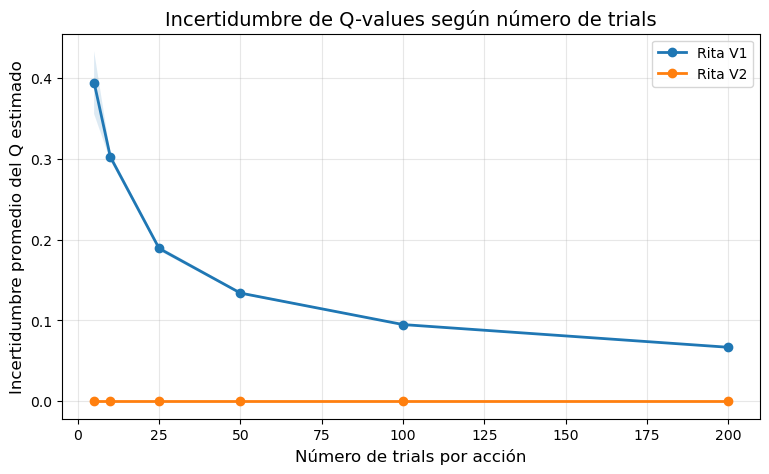

In [26]:
plt.figure()

for agent_label in df_q_quality["agent"].unique():
    part = df_q_quality[df_q_quality["agent"] == agent_label]
    plt.plot(part["n_trials"], part["mean_uncertainty"], marker="o", linewidth=2, label=agent_label)
    plt.fill_between(
        part["n_trials"],
        np.maximum(0, part["mean_uncertainty"] - part["ci_uncertainty"]),
        part["mean_uncertainty"] + part["ci_uncertainty"],
        alpha=0.15,
    )

plt.xlabel("Número de trials por acción")
plt.ylabel("Incertidumbre promedio del Q estimado")
plt.title("Incertidumbre de Q-values según número de trials")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


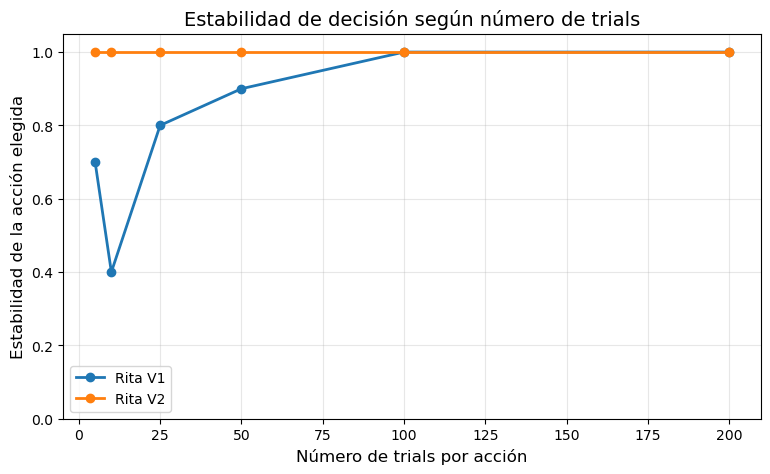

In [27]:
plt.figure()

for agent_label in df_q_quality["agent"].unique():
    part = df_q_quality[df_q_quality["agent"] == agent_label]
    plt.plot(part["n_trials"], part["agreement_rate"], marker="o", linewidth=2, label=agent_label)

plt.ylim(0, 1.05)
plt.xlabel("Número de trials por acción")
plt.ylabel("Estabilidad de la acción elegida")
plt.title("Estabilidad de decisión según número de trials")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Análisis del Experimento D

La incertidumbre de Q-values evidencia que MCTS depende de estimaciones por muestreo.  
Con pocos trials, las estimaciones son más ruidosas y la acción elegida puede cambiar entre recorridos.  
Este resultado también muestra una limitación de la recompensa terminal simple: estados no terminales distintos pueden recibir recompensa `0`, aun cuando su valor estratégico sea diferente.


# 11. Experimento E — Comparación directa V1 vs V2


In [28]:
direct_rows = []

for repeat in range(N_REPEATS):
    print(f"Comparación directa {repeat + 1}/{N_REPEATS}")

    df_direct = evaluate_matchup(
        "Rita V1",
        lambda seed: make_v1(seed + repeat * 100, **V1_PARAMS),
        "Rita V2",
        lambda seed: make_v2(seed + repeat * 100, **V2_PARAMS),
        n_games=GAMES_PER_REPEAT,
        timeout=TIMEOUT_PER_GAME,
        alternate_colors=True,
    )

    direct_rows.append({"repeat": repeat + 1, "agent": "Rita V1", "win_rate": float((df_direct["winner"] == "Rita V1").mean())})
    direct_rows.append({"repeat": repeat + 1, "agent": "Rita V2", "win_rate": float((df_direct["winner"] == "Rita V2").mean())})

df_direct_raw = pd.DataFrame(direct_rows)

df_direct_summary = (
    df_direct_raw
    .groupby("agent")
    .agg(mean_win_rate=("win_rate", "mean"), ci_win_rate=("win_rate", ci95))
    .reset_index()
)

df_direct_summary


Comparación directa 1/10
Comparación directa 2/10
Comparación directa 3/10
Comparación directa 4/10
Comparación directa 5/10
Comparación directa 6/10
Comparación directa 7/10
Comparación directa 8/10
Comparación directa 9/10
Comparación directa 10/10


,agent,mean_win_rate,ci_win_rate
0,Rita V1,0.20,0.082641
1,Rita V2,0.77,0.087897


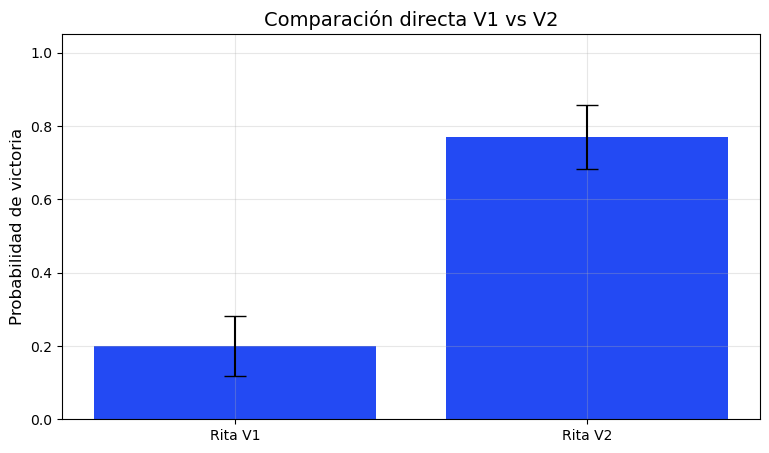

In [29]:
plt.figure()
plt.bar(
    df_direct_summary["agent"],
    df_direct_summary["mean_win_rate"],
    yerr=df_direct_summary["ci_win_rate"],
    capsize=8,
    color=PRIMARY_COLOR,
)
plt.ylim(0, 1.05)
plt.ylabel("Probabilidad de victoria")
plt.title("Comparación directa V1 vs V2")
plt.grid(axis="y", alpha=0.3)
plt.show()


# 12. Debilidades y cuellos de botella de Rita V2


## 12.1 No garantiza encontrar la jugada óptima

MCTS aproxima el valor de las acciones mediante simulaciones. No realiza una solución exhaustiva del árbol completo.  
La siguiente prueba compara Rita V2 contra rivales de dificultad creciente.


In [30]:
OPPONENTS = [
    ("Random", lambda seed: RandomPlayer(seed=seed)),
    ("Center", lambda seed: CenterPlayer()),
    ("Minimax depth 1", lambda seed: MinimaxPlayer(depth=1)),
    ("Minimax depth 2", lambda seed: MinimaxPlayer(depth=2)),
]

opponent_rows = []

for opponent_name, opponent_factory in OPPONENTS:
    print(f"Probando contra {opponent_name}...")
    for repeat in range(N_REPEATS):
        df = evaluate_matchup(
            "Rita V2",
            lambda seed: make_v2(seed + repeat * 100, num_iterations=500, time_limit=0.7),
            opponent_name,
            opponent_factory,
            n_games=GAMES_PER_REPEAT,
            timeout=TIMEOUT_PER_GAME,
            alternate_colors=True,
        )
        s = summarize_agent(df, "Rita V2")
        opponent_rows.append({
            "opponent": opponent_name,
            "repeat": repeat + 1,
            "win_rate": s["win_rate"],
            "loss_rate": s["loss_rate"],
            "draw_rate": s["draw_rate"],
        })

df_opponents = pd.DataFrame(opponent_rows)

df_opponents_summary = (
    df_opponents
    .groupby("opponent")
    .agg(
        mean_win_rate=("win_rate", "mean"),
        ci_win_rate=("win_rate", ci95),
        mean_loss_rate=("loss_rate", "mean"),
        mean_draw_rate=("draw_rate", "mean"),
    )
    .reset_index()
)

df_opponents_summary


Probando contra Random...
Probando contra Center...
Probando contra Minimax depth 1...
Probando contra Minimax depth 2...


,opponent,mean_win_rate,ci_win_rate,mean_loss_rate,mean_draw_rate
0,Center,0.94,0.052267,0.06,0.00
1,Minimax depth 1,1.00,0.000000,0.00,0.00
2,Minimax depth 2,0.71,0.054270,0.24,0.05
3,Random,1.00,0.000000,0.00,0.00


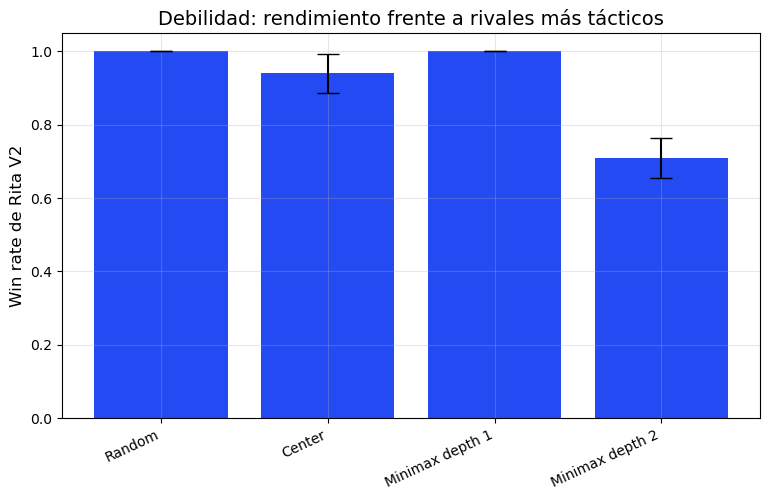

In [31]:
opponent_order = ["Random", "Center", "Minimax depth 1", "Minimax depth 2"]
df_opponents_plot = df_opponents_summary.copy()
df_opponents_plot["opponent"] = pd.Categorical(df_opponents_plot["opponent"], categories=opponent_order, ordered=True)
df_opponents_plot = df_opponents_plot.sort_values("opponent")

plt.figure()
plt.bar(
    df_opponents_plot["opponent"].astype(str),
    df_opponents_plot["mean_win_rate"],
    yerr=df_opponents_plot["ci_win_rate"],
    capsize=8,
    color=PRIMARY_COLOR,
)
plt.ylim(0, 1.05)
plt.ylabel("Win rate de Rita V2")
plt.title("Debilidad: rendimiento frente a rivales más tácticos")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 12.2 No reutiliza el árbol entre turnos

En cada llamada a `act()`, Rita V2 crea una nueva raíz de MCTS.  
Esto implica que las simulaciones de turnos anteriores se descartan.


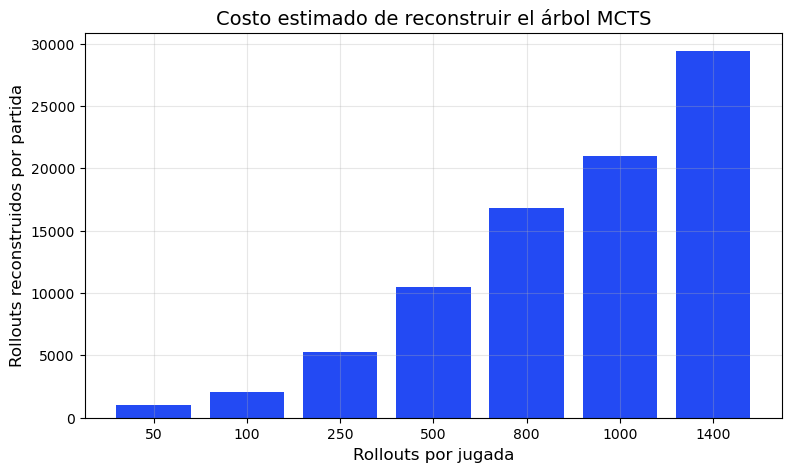

,num_iterations,estimated_agent_moves,estimated_rollouts_rebuilt_per_game,estimated_time_per_game
0,50,21,1050,8.571947
1,100,21,2100,19.659836
2,250,21,5250,23.064653
3,500,21,10500,24.350076
4,800,21,16800,24.543741
5,1000,21,21000,24.304406
6,1400,21,29400,24.711108


In [32]:
MAX_AGENT_MOVES = 21

df_rebuild = df_resource_summary.copy()
df_rebuild["estimated_agent_moves"] = MAX_AGENT_MOVES
df_rebuild["estimated_rollouts_rebuilt_per_game"] = df_rebuild["num_iterations"] * df_rebuild["estimated_agent_moves"]
df_rebuild["estimated_time_per_game"] = df_rebuild["mean_time"] * df_rebuild["estimated_agent_moves"]

plt.figure()
plt.bar(
    df_rebuild["num_iterations"].astype(str),
    df_rebuild["estimated_rollouts_rebuilt_per_game"],
    color=PRIMARY_COLOR,
)
plt.xlabel("Rollouts por jugada")
plt.ylabel("Rollouts reconstruidos por partida")
plt.title("Costo estimado de reconstruir el árbol MCTS")
plt.grid(axis="y", alpha=0.3)
plt.show()

df_rebuild[["num_iterations", "estimated_agent_moves", "estimated_rollouts_rebuilt_per_game", "estimated_time_per_game"]]


## 12.3 Posibles jugadas inseguras

Se generan tableros aleatorios no terminales.  
Se verifica si la acción elegida por Rita V2 permite al rival ganar inmediatamente, especialmente con bajo presupuesto de simulación.


In [33]:
def random_legal_board(seed, min_moves=8, max_moves=24):
    rng = np.random.default_rng(seed)
    board = new_board()
    player = P1

    n_moves = int(rng.integers(min_moves, max_moves + 1))

    for _ in range(n_moves):
        if is_terminal(board):
            break
        actions = legal_actions(board)
        if not actions:
            break
        col = int(rng.choice(actions))
        board = apply_move(board, col, player)
        player = opponent(player)

    if is_terminal(board):
        return None

    return board


def find_risky_examples(n_boards=150, num_iterations=80, time_limit=0.08, seed_offset=0):
    examples = []

    for i in range(n_boards):
        board = random_legal_board(seed=i + seed_offset)

        if board is None:
            continue

        player = current_player(board)
        actions = legal_actions(board)
        safe = safe_actions(board, player)

        if not safe:
            continue

        agent = make_v2(i, num_iterations=num_iterations, time_limit=time_limit)
        agent.mount(timeout=TIMEOUT_PER_GAME)
        chosen = int(agent.act(board.copy()))

        if chosen in actions and is_losing_move(board, chosen, player):
            examples.append({
                "board_id": i,
                "player": player,
                "chosen_action": chosen,
                "safe_actions": safe,
                "all_actions": actions,
                "board": board.copy(),
            })

    return examples


BUDGETS = [
    {"label": "bajo", "num_iterations": 50, "time_limit": 0.05},
    {"label": "medio", "num_iterations": 200, "time_limit": 0.20},
    {"label": "alto", "num_iterations": 800, "time_limit": 0.70},
]

risk_rows = []
risk_examples_by_budget = {}

for config in BUDGETS:
    print(f"Buscando jugadas inseguras con presupuesto {config['label']}...")
    examples = find_risky_examples(
        n_boards=150,
        num_iterations=config["num_iterations"],
        time_limit=config["time_limit"],
    )

    risk_examples_by_budget[config["label"]] = examples

    risk_rows.append({
        "budget": config["label"],
        "num_iterations": config["num_iterations"],
        "time_limit": config["time_limit"],
        "risky_examples": len(examples),
        "sampled_boards": 150,
        "risky_rate": len(examples) / 150,
    })

df_risk = pd.DataFrame(risk_rows)
df_risk


Buscando jugadas inseguras con presupuesto bajo...
Buscando jugadas inseguras con presupuesto medio...
Buscando jugadas inseguras con presupuesto alto...


,budget,num_iterations,time_limit,risky_examples,sampled_boards,risky_rate
0,bajo,50,0.05,2,150,0.013333
1,medio,200,0.20,1,150,0.006667
2,alto,800,0.70,1,150,0.006667


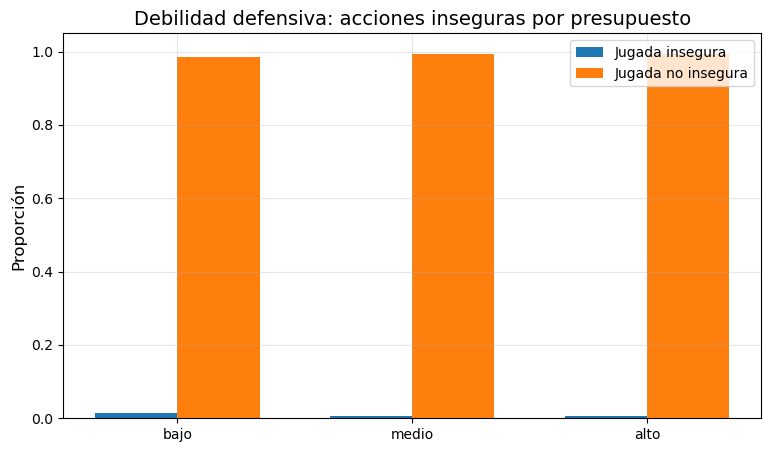

In [34]:
df_risk["safe_rate"] = 1.0 - df_risk["risky_rate"]

x = np.arange(len(df_risk))
width = 0.35

plt.figure()
plt.bar(x - width / 2, df_risk["risky_rate"], width, label="Jugada insegura")
plt.bar(x + width / 2, df_risk["safe_rate"], width, label="Jugada no insegura")
plt.xticks(x, df_risk["budget"])
plt.ylim(0, 1.05)
plt.ylabel("Proporción")
plt.title("Debilidad defensiva: acciones inseguras por presupuesto")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


## 12.4 Memoria de estados y recomputación

Los trials de Q-values evalúan repetidamente el mismo tablero base y sus acciones legales.  
Esto permite estimar un proxy de recomputación evitable mediante memoria de estados.


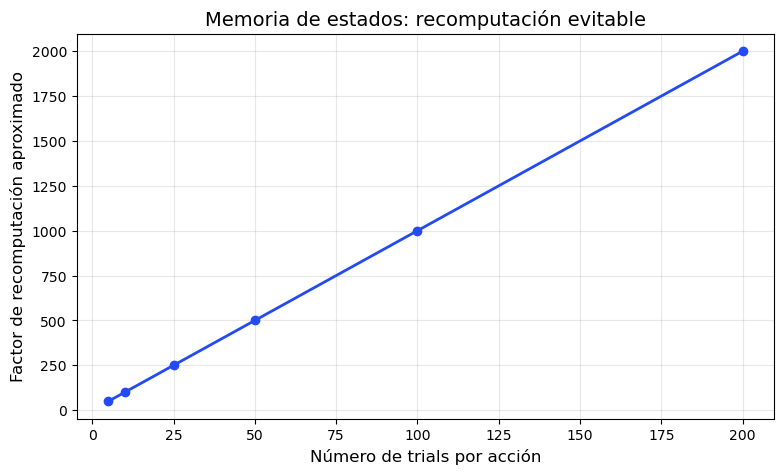

,n_trials,total_rollout_evaluations,unique_state_action_entries,recomputation_factor
6,5,350,7,50.0
7,10,700,7,100.0
8,25,1750,7,250.0
9,50,3500,7,500.0
10,100,7000,7,1000.0
11,200,14000,7,2000.0


In [35]:
num_legal_actions_test = len(legal_actions(test_board))

df_memory_proxy = df_q_quality[df_q_quality["agent"] == "Rita V2"].copy()
df_memory_proxy["legal_actions_in_test_board"] = num_legal_actions_test
df_memory_proxy["total_rollout_evaluations"] = (
    df_memory_proxy["n_trials"] * df_memory_proxy["legal_actions_in_test_board"] * Q_REPEATS
)
df_memory_proxy["unique_state_action_entries"] = df_memory_proxy["legal_actions_in_test_board"]
df_memory_proxy["recomputation_factor"] = (
    df_memory_proxy["total_rollout_evaluations"] / df_memory_proxy["unique_state_action_entries"]
)

plt.figure()
plt.plot(
    df_memory_proxy["n_trials"],
    df_memory_proxy["recomputation_factor"],
    marker="o",
    linewidth=2,
    color=PRIMARY_COLOR,
)
plt.xlabel("Número de trials por acción")
plt.ylabel("Factor de recomputación aproximado")
plt.title("Memoria de estados: recomputación evitable")
plt.grid(alpha=0.3)
plt.show()

df_memory_proxy[["n_trials", "total_rollout_evaluations", "unique_state_action_entries", "recomputation_factor"]]


## 12.5 Sensibilidad al parámetro `exploration_c`

Se evalúan valores fijos de `c` y una estrategia dinámica.  
La finalidad es demostrar que el balance exploración/explotación es un hiperparámetro relevante del agente.


In [36]:
C_VALUES = [0.3, 0.5, 0.8, 1.0, math.sqrt(2), 2.0, 3.0]
GAMES_PER_C_REPEAT = 6

c_rows = []

for c_value in C_VALUES:
    label = f"c={c_value:.3f}"
    print(f"Probando {label}...")

    for repeat in range(N_REPEATS):
        df = evaluate_matchup(
            label,
            lambda seed, c=c_value: FixedCPolicy(
                RitaV2Class,
                exploration_c=c,
                name=label,
                num_iterations=500,
                time_limit=0.7,
            ),
            "Minimax depth 2",
            lambda seed: MinimaxPlayer(depth=2),
            n_games=GAMES_PER_C_REPEAT,
            timeout=TIMEOUT_PER_GAME,
            alternate_colors=True,
        )

        s = summarize_agent(df, label)

        c_rows.append({
            "strategy": "fixed",
            "label": label,
            "c_value": c_value,
            "repeat": repeat + 1,
            "win_rate": s["win_rate"],
            "loss_rate": s["loss_rate"],
            "draw_rate": s["draw_rate"],
        })

dynamic_label = "dynamic c"

for repeat in range(N_REPEATS):
    df = evaluate_matchup(
        dynamic_label,
        lambda seed: DynamicCPolicy(
            RitaV2Class,
            name=dynamic_label,
            num_iterations=500,
            time_limit=0.7,
        ),
        "Minimax depth 2",
        lambda seed: MinimaxPlayer(depth=2),
        n_games=GAMES_PER_C_REPEAT,
        timeout=TIMEOUT_PER_GAME,
        alternate_colors=True,
    )

    s = summarize_agent(df, dynamic_label)

    c_rows.append({
        "strategy": "dynamic",
        "label": dynamic_label,
        "c_value": np.nan,
        "repeat": repeat + 1,
        "win_rate": s["win_rate"],
        "loss_rate": s["loss_rate"],
        "draw_rate": s["draw_rate"],
    })

df_c_experiment = pd.DataFrame(c_rows)

df_c_summary = (
    df_c_experiment
    .groupby(["strategy", "label", "c_value"], dropna=False)
    .agg(
        mean_win_rate=("win_rate", "mean"),
        ci_win_rate=("win_rate", ci95),
        mean_loss_rate=("loss_rate", "mean"),
        mean_draw_rate=("draw_rate", "mean"),
    )
    .reset_index()
)

df_c_summary


Probando c=0.300...
Probando c=0.500...
Probando c=0.800...
Probando c=1.000...
Probando c=1.414...
Probando c=2.000...
Probando c=3.000...


,strategy,label,c_value,mean_win_rate,ci_win_rate,mean_loss_rate,mean_draw_rate
0,dynamic,dynamic c,NaN,0.650000,0.076222,0.300000,0.050000
1,fixed,c=0.300,0.300000,0.916667,0.073045,0.050000,0.033333
2,fixed,c=0.500,0.500000,0.850000,0.076222,0.150000,0.000000
3,fixed,c=0.800,0.800000,0.750000,0.087789,0.233333,0.016667
4,fixed,c=1.000,1.000000,0.700000,0.081485,0.250000,0.050000
5,fixed,c=1.414,1.414214,0.633333,0.065333,0.333333,0.033333
6,fixed,c=2.000,2.000000,0.583333,0.111578,0.316667,0.100000
7,fixed,c=3.000,3.000000,0.616667,0.049899,0.366667,0.016667


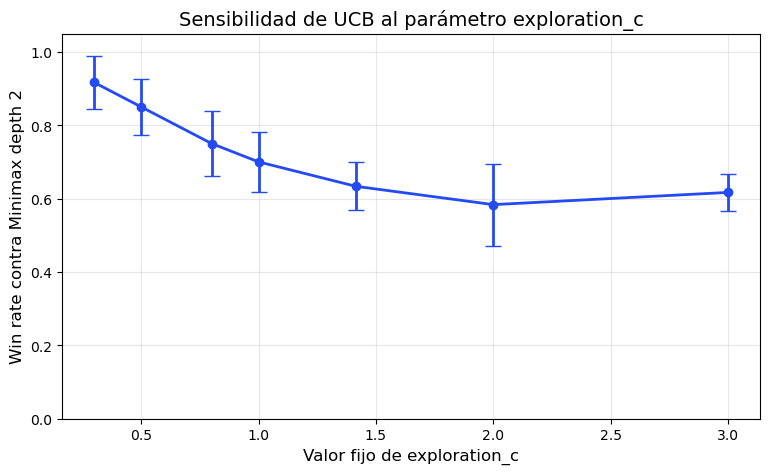

In [37]:
df_fixed_c = df_c_summary[df_c_summary["strategy"] == "fixed"].copy().sort_values("c_value")

plt.figure()
plt.errorbar(
    df_fixed_c["c_value"],
    df_fixed_c["mean_win_rate"],
    yerr=df_fixed_c["ci_win_rate"],
    marker="o",
    linewidth=2,
    capsize=6,
    color=PRIMARY_COLOR,
)
plt.ylim(0, 1.05)
plt.xlabel("Valor fijo de exploration_c")
plt.ylabel("Win rate contra Minimax depth 2")
plt.title("Sensibilidad de UCB al parámetro exploration_c")
plt.grid(alpha=0.3)
plt.show()


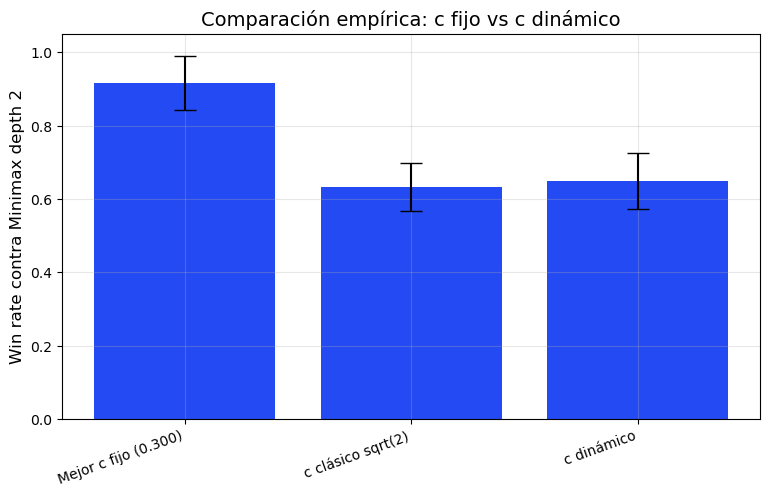

,config,mean_win_rate,ci_win_rate
0,Mejor c fijo (0.300),0.916667,0.073045
1,c clásico sqrt(2),0.633333,0.065333
2,c dinámico,0.650000,0.076222


In [38]:
best_fixed_row = df_fixed_c.sort_values(["mean_win_rate", "ci_win_rate"], ascending=[False, True]).iloc[0]
classic_row = df_fixed_c.iloc[(df_fixed_c["c_value"] - math.sqrt(2)).abs().argsort()].iloc[0]
dynamic_row = df_c_summary[df_c_summary["strategy"] == "dynamic"].iloc[0]

df_c_compare = pd.DataFrame([
    {
        "config": f"Mejor c fijo ({best_fixed_row['c_value']:.3f})",
        "mean_win_rate": best_fixed_row["mean_win_rate"],
        "ci_win_rate": best_fixed_row["ci_win_rate"],
    },
    {
        "config": "c clásico sqrt(2)",
        "mean_win_rate": classic_row["mean_win_rate"],
        "ci_win_rate": classic_row["ci_win_rate"],
    },
    {
        "config": "c dinámico",
        "mean_win_rate": dynamic_row["mean_win_rate"],
        "ci_win_rate": dynamic_row["ci_win_rate"],
    },
])

plt.figure()
plt.bar(
    df_c_compare["config"],
    df_c_compare["mean_win_rate"],
    yerr=df_c_compare["ci_win_rate"],
    capsize=8,
    color=PRIMARY_COLOR,
)
plt.ylim(0, 1.05)
plt.ylabel("Win rate contra Minimax depth 2")
plt.title("Comparación empírica: c fijo vs c dinámico")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

df_c_compare


# 13. Síntesis final de resultados


In [39]:
best_resource = df_resource_summary.sort_values(["mean_win_rate", "mean_time"], ascending=[False, True]).iloc[0]

v1_vs_random = df_comparison_summary[df_comparison_summary["agent"] == "Rita V1"].iloc[0]
v2_vs_random = df_comparison_summary[df_comparison_summary["agent"] == "Rita V2"].iloc[0]

v1_direct = df_direct_summary[df_direct_summary["agent"] == "Rita V1"].iloc[0]
v2_direct = df_direct_summary[df_direct_summary["agent"] == "Rita V2"].iloc[0]

hardest_opponent = df_opponents_plot.sort_values("mean_win_rate").iloc[0]
highest_risk = df_risk.sort_values("risky_rate", ascending=False).iloc[0]
highest_recompute = df_memory_proxy.sort_values("recomputation_factor", ascending=False).iloc[0]

summary_table = pd.DataFrame({
    "Dimensión": [
        "Mejora global",
        "Comparación directa",
        "Rollouts",
        "Rollout táctico",
        "Q-values",
        "No optimalidad",
        "Acciones inseguras",
        "Memoria de estados",
        "Exploration c",
    ],
    "Evidencia": [
        f"V1 vs Random: {v1_vs_random['mean_win_rate']:.2%}; V2 vs Random: {v2_vs_random['mean_win_rate']:.2%}",
        f"V1 directo: {v1_direct['mean_win_rate']:.2%}; V2 directo: {v2_direct['mean_win_rate']:.2%}",
        f"Mejor eficiencia observada: {int(best_resource['num_iterations'])} rollouts, tiempo {best_resource['mean_time']:.4f}s",
        "Ablación entre V2 con rollout aleatorio y V2 con rollout táctico.",
        "La incertidumbre de Q disminuye al aumentar trials.",
        f"Peor desempeño observado contra {hardest_opponent['opponent']}: {hardest_opponent['mean_win_rate']:.2%}",
        f"Mayor tasa de acciones inseguras: {highest_risk['risky_rate']:.2%} con presupuesto {highest_risk['budget']}",
        f"Factor máximo de recomputación aproximado: {highest_recompute['recomputation_factor']:.1f}x",
        "El barrido de c evalúa sensibilidad al balance exploración/explotación.",
    ],
    "Conclusión técnica": [
        "V2 mejora la calidad de búsqueda respecto a V1.",
        "El enfrentamiento directo cuantifica superioridad relativa.",
        "Más rollouts elevan capacidad de búsqueda, pero también costo temporal.",
        "La default policy táctica reduce ruido frente a simulación aleatoria.",
        "MCTS depende de estimaciones por muestreo.",
        "MCTS no garantiza optimalidad frente a búsqueda adversarial.",
        "Un filtro de safe actions puede fortalecer defensa.",
        "Una memoria de estados reduciría recomputación.",
        "Un c fijo puede ser subóptimo; el ajuste dinámico es una mejora plausible.",
    ],
})

summary_table


,Dimensión,Evidencia,Conclusión técnica
0,Mejora global,V1 vs Random: 100.00%; V2 vs Random: 100.00%,V2 mejora la calidad de búsqueda respecto a V1.
1,Comparación directa,V1 directo: 20.00%; V2 directo: 77.00%,El enfrentamiento directo cuantifica superiori...
2,Rollouts,"Mejor eficiencia observada: 50 rollouts, tiemp...","Más rollouts elevan capacidad de búsqueda, per..."
3,Rollout táctico,Ablación entre V2 con rollout aleatorio y V2 c...,La default policy táctica reduce ruido frente ...
4,Q-values,La incertidumbre de Q disminuye al aumentar tr...,MCTS depende de estimaciones por muestreo.
5,No optimalidad,Peor desempeño observado contra Minimax depth ...,MCTS no garantiza optimalidad frente a búsqued...
6,Acciones inseguras,Mayor tasa de acciones inseguras: 1.33% con pr...,Un filtro de safe actions puede fortalecer def...
7,Memoria de estados,Factor máximo de recomputación aproximado: 200...,Una memoria de estados reduciría recomputación.
8,Exploration c,El barrido de c evalúa sensibilidad al balance...,Un c fijo puede ser subóptimo; el ajuste dinám...


# 14. Conclusión

La evolución de Rita V1 a Rita V2 mantiene la base algorítmica de MCTS + UCB, pero mejora la calidad de estimación mediante mayor presupuesto de simulación y una política de rollout más informada. El análisis empírico permite afirmar que V2 constituye una mejora razonable frente a V1, especialmente por la reducción de aleatoriedad en las simulaciones y el aumento de recursos de búsqueda.

No obstante, Rita V2 conserva limitaciones estructurales. No garantiza encontrar la jugada óptima, depende del número de rollouts, usa una recompensa simple en backpropagation, reconstruye el árbol en cada turno, no mantiene memoria de estados y es sensible al parámetro `exploration_c`.

Las mejoras futuras técnicamente justificadas son:

1. Filtro de acciones seguras antes de MCTS.
2. Recompensa heurística para estados no terminales.
3. Reutilización del árbol entre turnos.
4. Memoria de estados o tabla de transposición.
5. Calibración empírica o ajuste dinámico de `exploration_c`.
6. Verificación táctica con minimax/alpha-beta de baja profundidad.
